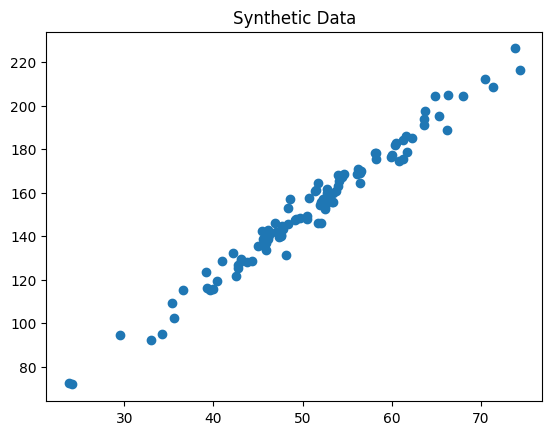

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Synthetic data
X = np.random.randn(100, 1) * 10 + 50
noise = np.random.randn(100, 1) * 5
y = 3 * X + noise
plt.scatter(X, y)
plt.title("Synthetic Data")
plt.show()

In [4]:
# Cost function
def costfunc(w: int, b: int, x: np.ndarray, y: np.ndarray) -> float:
    m = x.shape[0]
    sum = 0
    for i in range(m):
        sum += (w*x[i] + b - y[i])**2
    return sum//(2*m)

def mse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
         return np.mean((y_true - y_pred) ** 2)

Text(0.5, 1.0, 'W vs. Cost function')

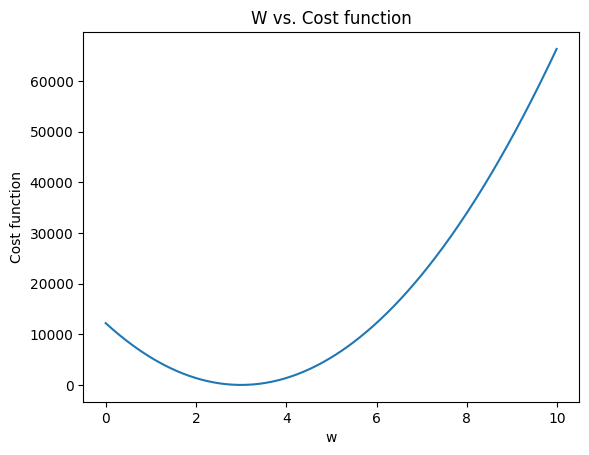

In [5]:
w = np.arange(0, 10, 0.01)
j_w=[]
for i in w:
    j_w.append(costfunc(i, 0, X, y))
plt.plot(w, j_w)
plt.xlabel('w')
plt.ylabel('Cost function')
plt.title('W vs. Cost function')

Text(0.5, 1.0, 'b vs. Cost function')

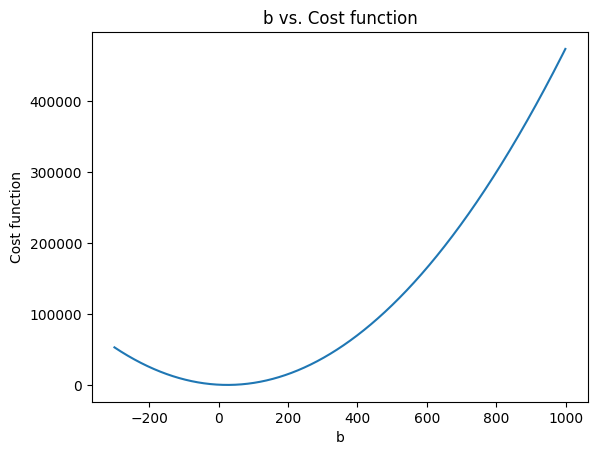

In [8]:
b = np.arange(-300, 1000)
j_b=[]
for i in b:
    j_b.append(costfunc(2.5, i, X, y))
plt.plot(b, j_b)
plt.xlabel('b')
plt.ylabel('Cost function')
plt.title('b vs. Cost function')

In [7]:
def compute_gradient(x, y, w, b): 
    m = x.shape[0]    
    dj_dw = 0
    dj_db = 0
    for i in range(m):  
        f_wb = w * x[i] + b 
        dj_db += f_wb - y[i] 
        dj_dw += (f_wb - y[i]) * x[i] 
    return dj_dw / m, dj_db / m

def gradient_descent(x, y, w_in, b_in, alpha, num_iters): 
    J_history = []
    b = b_in
    w = w_in
    
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(x, y, w , b)     
        b = b - alpha * dj_db                            
        w = w - alpha * dj_dw                            
        if i<100000:
            J_history.append(costfunc(w, b, x, y))
    return w, b, J_history


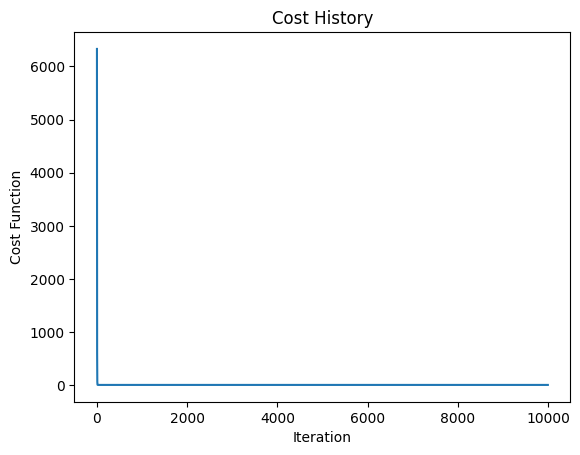

Final Weights: w=2.9836, b=0.2160


In [9]:
w_final, b_final, J_history = gradient_descent(X, y, 0, 0, 0.0001, 10000)

# Plot cost history
plt.plot(J_history)
plt.title("Cost History")
plt.xlabel("Iteration")
plt.ylabel("Cost Function")
plt.show()

print(f"Final Weights: w={w_final[0]:.4f}, b={b_final[0]:.4f}")

In [10]:
from sklearn.linear_model import LinearRegression

sk_model = LinearRegression()
sk_model.fit(X, y)

print("--- Comparison ---")
print(f"Manual  - w: {w_final[0]:.4f}, b: {b_final[0]:.4f}")
print(f"Sklearn - w: {sk_model.coef_[0][0]:.4f}, b: {sk_model.intercept_[0]:.4f}")

--- Comparison ---
Manual  - w: 2.9836, b: 0.2160
Sklearn - w: 2.9140, b: 3.8096
